<a href="https://colab.research.google.com/github/mkg6573/Social_media_impact_on_life_ML_/blob/main/Supervised%20Learning%20Algorithms/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/Social_media_impact_on_life_Clean_Dataset.csv")
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,4.4,Negative


In [4]:
df.shape

(1705, 9)

In [5]:
df = df.drop('Mental_Health_Score', axis=1)

In [6]:
df.shape

(1705, 8)

In [7]:
X = df.drop("Overall_Impact", axis=1)
y = df["Overall_Impact"]

Separate Numerical and Categorical Columns

In [13]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

Create Preprocessing Pipeline

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [15]:
# Numerical columns pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical columns pipeline
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [16]:
# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model various value of max_depth

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

depths = []
accuracies = []

# Try different max_depth values
for depth in range(1, 21):

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    depths.append(depth)
    accuracies.append(acc)

    print(f"Max Depth: {depth}  Accuracy: {acc:.4f}")

Max Depth: 1  Accuracy: 0.7713
Max Depth: 2  Accuracy: 0.8592
Max Depth: 3  Accuracy: 0.8798
Max Depth: 4  Accuracy: 0.8915
Max Depth: 5  Accuracy: 0.9120
Max Depth: 6  Accuracy: 0.9267
Max Depth: 7  Accuracy: 0.9208
Max Depth: 8  Accuracy: 0.9208
Max Depth: 9  Accuracy: 0.9208
Max Depth: 10  Accuracy: 0.9179
Max Depth: 11  Accuracy: 0.9267
Max Depth: 12  Accuracy: 0.9267
Max Depth: 13  Accuracy: 0.9326
Max Depth: 14  Accuracy: 0.9267
Max Depth: 15  Accuracy: 0.9267
Max Depth: 16  Accuracy: 0.9296
Max Depth: 17  Accuracy: 0.9296
Max Depth: 18  Accuracy: 0.9296
Max Depth: 19  Accuracy: 0.9296
Max Depth: 20  Accuracy: 0.9296


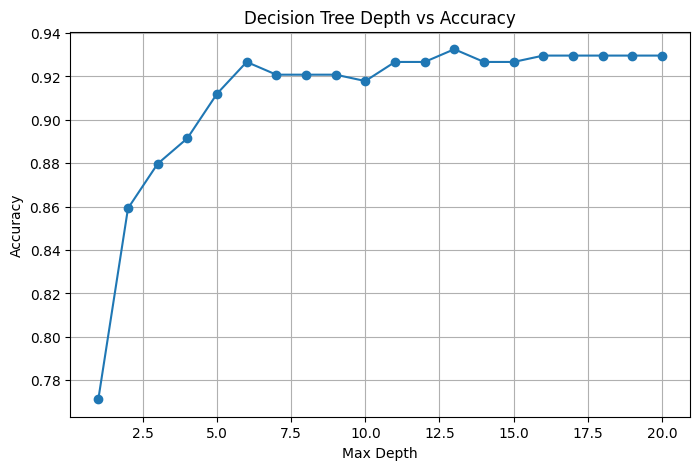

In [21]:
# Draw graph
plt.figure(figsize=(8,5))

plt.plot(depths, accuracies, marker='o')

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")

plt.grid(True)

plt.show()

If max_depth = 7 gives the highest test accuracy

In [22]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('model', DecisionTreeClassifier(
        max_depth=7,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Final Accuracy:", acc)

Final Accuracy: 0.9208211143695014


In [23]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('model', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=7,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Final Accuracy:", acc)

Final Accuracy: 0.9149560117302052


Using criterion='entropy' decreased the model accuracy compared to gini, which means Gini impurity created better splits for this dataset.

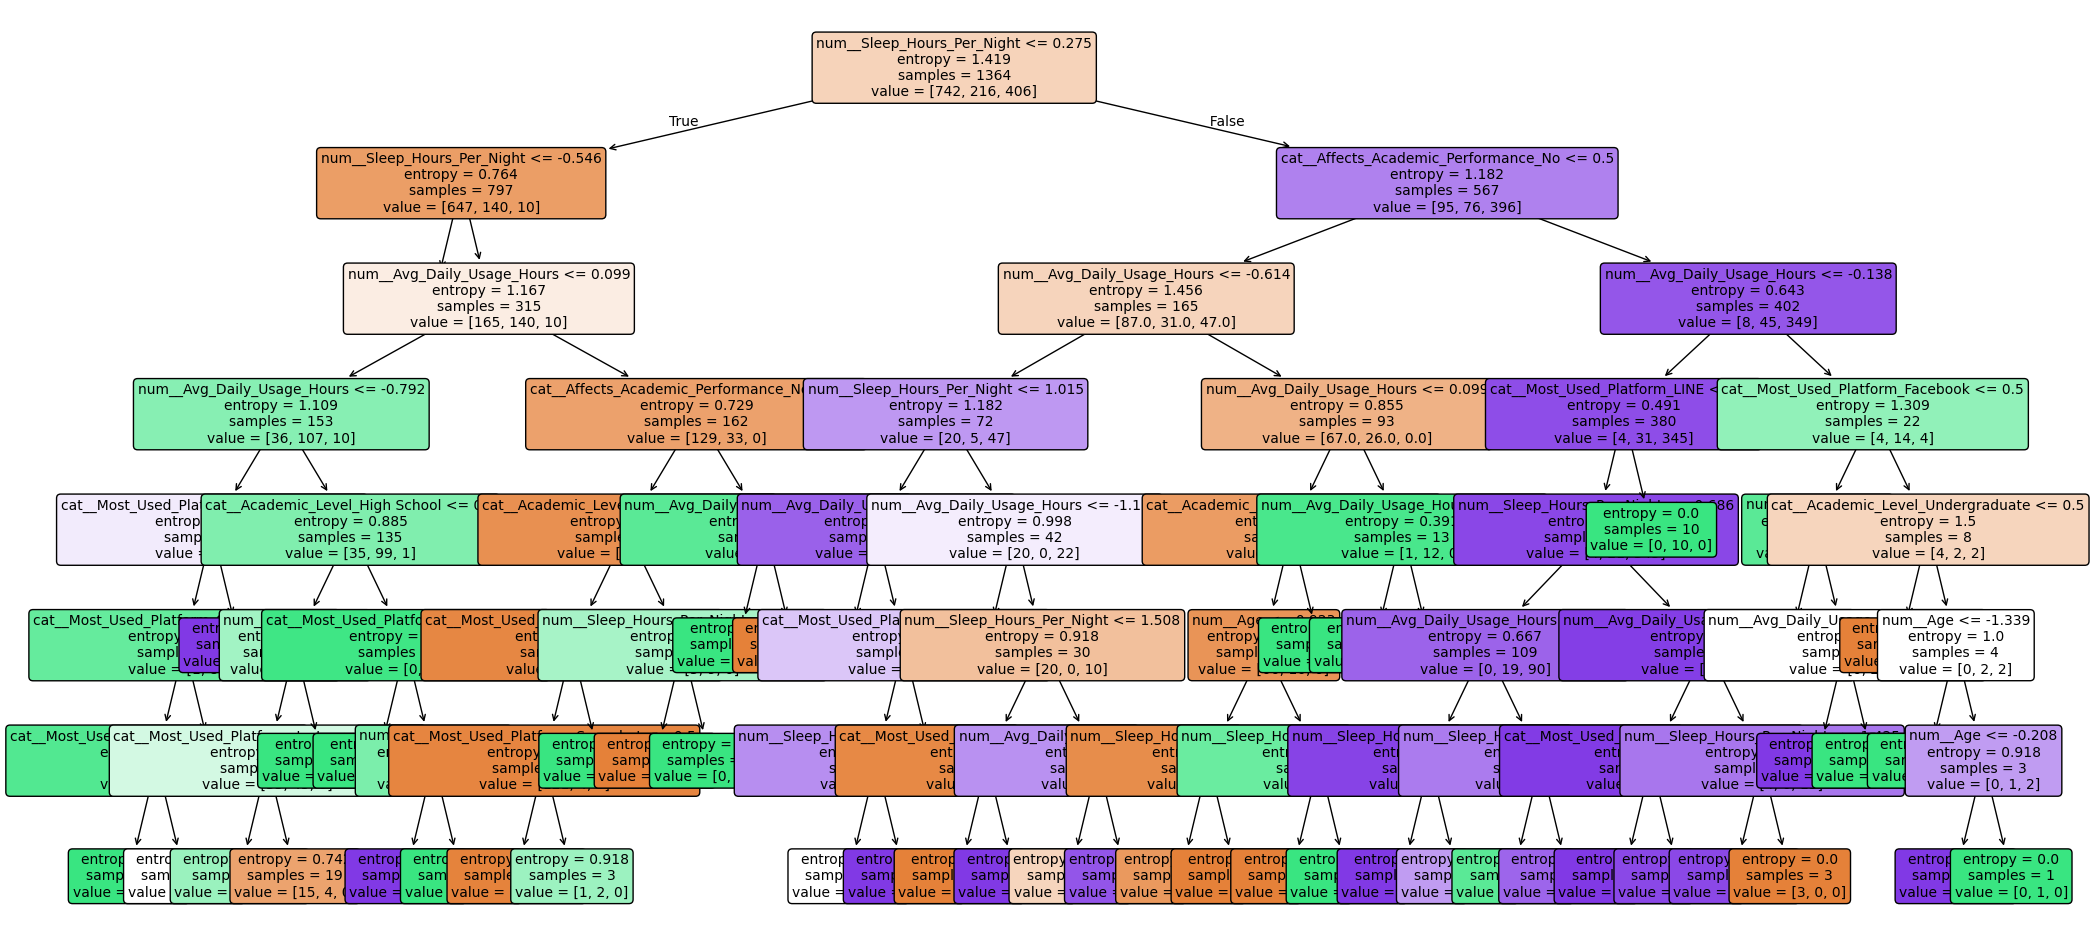

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extract trained model from pipeline
tree_model = pipeline.named_steps['model']

# Get feature names after preprocessing
feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

# Plot the decision tree
plt.figure(figsize=(25,12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

#**So we have accuracy of 92.08%**